In [ ]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier, Pool, cv
from sklearn.model_selection import train_test_split

from .utils.extract_features import extract_features

import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [2]:
class XSSLearnDetector:
    """Класс для детектирования XSS с мониторингом"""

    def __init__(self, model_path=None):
        if model_path:
            self.model, self.metadata = self.load_model()
        else:
            self.model = None
            self.metadata = None

        # Статистика использования
        self.stats = {
            'total_predictions': 0,
            'xss_detected': 0,
            'false_positives': 0,
            'false_negatives': 0
        }

    def train(self, csv_file):
        """Обучение модели"""
        self.model, _ = full_training_pipeline(csv_file)

    def predict(self, code, threshold=0.5):
        """Предсказание с порогом"""
        if not self.model:
            raise ValueError("Модель не обучена!")

        self.stats['total_predictions'] += 1

        result = self.predict_xss(self.model, code, self.metadata)

        # Применяем порог
        final_prediction = result['probability'] >= threshold

        # Обновляем статистику
        if final_prediction:
            self.stats['xss_detected'] += 1

        return {
            'prediction': final_prediction,
            'probability': result['probability'],
            'details': result
        }

    def save_model(self, model, feature_names, cat_features, scaler=None):
        """Сохраняет модель и метаданные"""

        model_filename = "./model/catboost_xss_model.cbm"
        metadata_filename = "./model/model_metadata.pkl"

        # Сохраняем модель
        model.save_model(model_filename)

        # Сохраняем метаданные
        metadata = {
            'feature_names': list(feature_names),
            'cat_features': cat_features,
            'model_type': 'CatBoost',
            'version': '1.0'
        }

        joblib.dump(metadata, metadata_filename)

        if scaler:
            joblib.dump(scaler, 'scaler.pkl')

        print("💾 Модель сохранена:")
        print(f"  - {model_filename} (модель)")
        print(f"  - {metadata_filename} (метаданные)")

        return model_filename, metadata_filename

    def load_model(self):
        """Загружает модель и метаданные"""
        model = CatBoostClassifier()
        model.load_model('catboost_xss_model.cbm')
        metadata = joblib.load('model_metadata.pkl')

        print("📤 Модель загружена")
        return model, metadata

    def predict_xss(self, model, text, metadata):
        """Предсказывает XSS для нового кода"""

        # Извлекаем признаки
        features = extract_features(text)
        features_df = pd.DataFrame([features])

        # Убеждаемся, что порядок признаков правильный
        features_df = features_df[metadata['feature_names']]

        # Преобразуем категориальные признаки
        for col in metadata['cat_features']:
            if col in features_df.columns:
                features_df[col] = features_df[col].astype('category')

        # Предсказание
        prediction = model.predict(features_df)[0]
        probability = model.predict_proba(features_df)[0][1]

        # Интерпретация
        result = {
            'text': text[:100] + '...' if len(text) > 100 else text,
            'is_xss': bool(prediction),
            'probability': float(probability),
            'risk_level': 'HIGH' if probability > 0.7 else 'MEDIUM' if probability > 0.3 else 'LOW'
        }

        # Детальный анализ
        if probability > 0.5:
            # Анализируем, какие признаки вызвали срабатывание
            feature_importance = model.get_feature_importance(
                data=Pool(features_df, cat_features=metadata['cat_features'], text_features=['text']),
                type='PredictionValuesChange'
            )

            top_features_idx = np.argsort(feature_importance)[-3:][::-1]
            top_features = []
            for idx in top_features_idx:
                if feature_importance[idx] > 0:
                    top_features.append(
                        f"{metadata['feature_names'][idx]}: {features[metadata['feature_names'][idx]]}"
                    )

            result['triggered_features'] = top_features

        return result

    def batch_predict(self, model, texts, metadata):
        """Пакетное предсказание"""
        results = []
        for text in texts:
            results.append(self.predict_xss(model, text, metadata))
        return pd.DataFrame(results)

    def evaluate_on_dataset(self, test_csv, threshold=0.5):
        """Оценка на тестовом датасете"""
        test_df = pd.read_csv(test_csv)

        predictions = []
        probabilities = []

        for text in test_df['text']:
            result = self.predict(text, threshold)
            predictions.append(result['prediction'])
            probabilities.append(result['probability'])

        y_true = test_df['label'].values
        y_pred = np.array(predictions)

        print("\n📊 Оценка на тестовом датасете:")
        print(classification_report(y_true, y_pred))
        print(f"AUC: {roc_auc_score(y_true, probabilities):.4f}")

        # Обновляем статистику ошибок
        cm = confusion_matrix(y_true, y_pred)
        self.stats['false_positives'] += cm[0, 1]
        self.stats['false_negatives'] += cm[1, 0]

        return classification_report(y_true, y_pred, output_dict=True)

    def get_stats(self):
        """Получить статистику"""
        return self.stats.copy()


In [ ]:
def train_final_model(X, y, cat_features, params):
    """Обучает финальную модель на всех данных"""

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    train_pool = Pool(X_train, y_train, cat_features=cat_features, text_features=['text'])
    val_pool = Pool(X_val, y_val, cat_features=cat_features, text_features=['text'])

    print("🚀 Обучение финальной модели...")

    model = CatBoostClassifier(**params)

    model.fit(
        train_pool,
        eval_set=val_pool,
        verbose=100,
        plot=True
    )

    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]

    print("\n📈 Метрики на валидационной выборке:")
    print(classification_report(y_val, y_pred))
    print(f"AUC: {roc_auc_score(y_val, y_pred_proba):.4f}")

    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal (0)', 'XSS (1)'],
            yticklabels=['Normal (0)', 'XSS (1)'])
    plt.title('Матрица ошибок обучение')
    plt.ylabel('Истинные значения')
    plt.xlabel('Предсказанные значения')
    plt.savefig('./confusion_matrix.png')
    plt.show()

    return model

In [ ]:
def load_and_prepare_data(csv_file, with_label: bool = True):
    """Загружает CSV и преобразует в признаки"""
    print("📥 Загрузка данных...")
    df = pd.read_csv(csv_file)

    print("🔧 Извлечение признаков...")
    features_list = []
    for i, text in enumerate(df['text']):
        if i % 500 == 0:
            print(f"  Обработано {i}/{len(df)}...")
        features_list.append(extract_features(text))

    X = pd.DataFrame(features_list)
    y = df['label'].values if with_label else None

    print(
        f"✅ Данные подготовлены: {X.shape[0]} примеров, {X.shape[1]} признаков")
    if with_label:
        print(
            f"📊 Распределение классов: {y.sum()} XSS, {len(y)-y.sum()} нормальных")

    return X, y


def get_categorical_features(X: pd.DataFrame):
    """Определяет, какие признаки категориальные"""
    categorical = []

    for col in X.columns:
        if X[col].nunique() <= 8 and set(X[col].unique()).issubset({0, 1}):
            categorical.append(col)

    print(f"🎯 Категориальные признаки ({len(categorical)}): {categorical}")
    return categorical


def train_with_cross_validation(X, y, cat_features):
    """Обучает CatBoost с кросс-валидацией"""

    pool = Pool(data=X, label=y, cat_features=cat_features, text_features=['text'])

    params = {
        'iterations': 10000,
        'depth': 6,
        'learning_rate': 0.05,
        'loss_function': 'Logloss',
        'verbose': 100,
        'random_seed': 42,
        'task_type': 'GPU',
        'eval_metric': 'AUC',
        'early_stopping_rounds': 50,
        'use_best_model': True,
        'bootstrap_type': 'Bernoulli',
        'subsample': 0.8,
        'l2_leaf_reg': 3,
        'metric_period': 50,
        'devices': '0:1'
    }

    print("🔄 Начинаю кросс-валидацию...")

    # 5-фолдная кросс-валидация
    cv_data = cv(
        pool=pool,
        params=params,
        fold_count=5,
        shuffle=True,
        partition_random_seed=42,
        stratified=True,
        verbose=False,
        plot=True
    )

    print("\n📊 Результаты кросс-валидации:")
    print(f"Лучшая AUC на валидации: {cv_data['test-AUC-mean'].max():.4f}")
    print(
        f"Среднее AUC: {cv_data['test-AUC-mean'].mean():.4f} ± {cv_data['test-AUC-std'].mean():.4f}")

    return cv_data, params


def analyze_feature_importance(model, X):
    """Анализирует важность признаков"""

    # Получаем важность признаков
    feature_importance = model.get_feature_importance()
    feature_names = X.columns

    # Создаем DataFrame
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)

    # Визуализация
    plt.figure(figsize=(12, 30))
    plt.barh(range(len(importance_df)), importance_df['importance'])
    plt.yticks(range(len(importance_df)), importance_df['feature'])
    plt.xlabel('Важность')
    plt.title('Важность признаков (CatBoost)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('./features.png')
    plt.show()

    return importance_df

In [6]:
class XSSTestDetector:
    """Класс для детектирования XSS с загруженной моделью"""

    def __init__(self, model_path='catboost_xss_model.cbm',
                 metadata_path='model_metadata.pkl'):
        self.model_path = model_path
        self.metadata_path = metadata_path
        self.model = None
        self.metadata = None
        self.load_model()

    def load_model(self):
        """Загружает модель из файлов"""
        try:
            self.model = CatBoostClassifier()
            self.model.load_model(self.model_path)

            self.metadata = joblib.load(self.metadata_path)

            print(f"✅ Модель успешно загружена")
            print(f"   Признаков: {len(self.metadata['feature_names'])}")
            print(
                f"   Категориальных: {len(self.metadata.get('cat_features', []))}")

        except Exception as e:
            print(f"❌ Ошибка загрузки модели: {e}")
            raise

    def prepare_features(self, features_dict):
        """Подготовка признаков для модели"""
        features_df = pd.DataFrame([features_dict])

        expected_features = self.metadata['feature_names']
        for feature in expected_features:
            if feature not in features_df.columns:
                features_df[feature] = 0  # Заполняем недостающие нулями

        features_df = features_df[expected_features]

        cat_features = self.metadata.get('cat_features', [])
        for col in cat_features:
            if col in features_df.columns:
                features_df[col] = features_df[col].astype('category')

        return features_df

    def predict(self, code, threshold=0.5):
        """
        Предсказывает, является ли код XSS

        Args:
            code (str): HTML/JS код для проверки
            threshold (float): Порог вероятности (0.5 по умолчанию)

        Returns:
            dict: Результат предсказания
        """
        if self.model is None:
            raise ValueError("Модель не загружена!")

        features = extract_features(code)

        features_df = self.prepare_features(features)

        prediction = self.model.predict(features_df)[0]
        probability = self.model.predict_proba(features_df)[0][1]

        is_xss = probability >= threshold

        return {
            'is_xss': bool(is_xss),
            'probability': float(probability),
            'prediction': prediction,
            'threshold': threshold,
            'code_sample': code[:100] + '...' if len(code) > 100 else code,
            'risk_level': self._get_risk_level(probability),
            'features': self._get_top_features(features_df, features)
        }

    def predict_batch(self, codes, threshold=0.5):
        """Пакетное предсказание"""
        results = []
        for code in codes:
            results.append(self.predict(code, threshold, return_details=True))
        return pd.DataFrame(results)

    def _get_risk_level(self, probability):
        """Определяет уровень риска"""
        if probability >= 0.8:
            return "CRITICAL"
        elif probability >= 0.6:
            return "HIGH"
        elif probability >= 0.4:
            return "MEDIUM"
        elif probability >= 0.2:
            return "LOW"
        else:
            return "SAFE"

    def _get_top_features(self, features_df, original_features):
        """Возвращает топ признаков, повлиявших на решение"""
        try:
            # Получаем важность признаков для этого конкретного предсказания
            shap_values = self.model.get_feature_importance(
                data=features_df,
                type='PredictionValuesChange'
            )

            # Сортируем по важности
            feature_names = self.metadata['feature_names']
            important = []

            for idx in np.argsort(shap_values)[-5:][::-1]:
                if shap_values[idx] > 0:
                    feature_name = feature_names[idx]
                    feature_value = original_features.get(feature_name, 0)
                    important.append(f"{feature_name}={feature_value}")

            return important
        except:
            return []

    def get_model_info(self):
        """Информация о модели"""
        if self.model is None:
            return "Модель не загружена"

        info = {
            'model_type': 'CatBoost',
            'feature_count': len(self.metadata['feature_names']),
            'cat_features': len(self.metadata.get('cat_features', [])),
            'tree_count': self.model.tree_count_ if hasattr(self.model, 'tree_count_') else 'N/A',
            'classes': list(self.model.classes_) if hasattr(self.model, 'classes_') else [0, 1]
        }

        return info

In [7]:
train_filename = './XSS_dataset.csv'
test_filename = './datasets_test/xss_dataset.csv'

In [ ]:
print("\n" + "="*60)
print("НАЧАЛО ОБУЧЕНИЯ МОДЕfЛИ DETECT XSS")
print("="*60 + "\n")

print("=" * 60)
print("🚀 ЗАПУСК ПОЛНОГО ПАЙПЛАЙНА ОБУЧЕНИЯ CATBOOST")
print("=" * 60)

learn_detector = XSSLearnDetector()

X, y = load_and_prepare_data(train_filename)

cat_features = get_categorical_features(X)

feature_weights = []

for f in cat_features:
    if 'js' in f:
        feature_weights.append(1.0)
    if 'html' in f:
        feature_weights.append(0.7)
    else:
        feature_weights.append(0.5)


cv_results, best_params = train_with_cross_validation(X, y, cat_features)


НАЧАЛО ОБУЧЕНИЯ МОДЕЛИ DETECT XSS

🚀 ЗАПУСК ПОЛНОГО ПАЙПЛАЙНА ОБУЧЕНИЯ CATBOOST
📥 Загрузка данных...
🔧 Извлечение признаков...
  Обработано 0/13686...
  Обработано 500/13686...
  Обработано 1000/13686...
  Обработано 1500/13686...
  Обработано 2000/13686...
  Обработано 2500/13686...
  Обработано 3000/13686...
  Обработано 3500/13686...
  Обработано 4000/13686...
  Обработано 4500/13686...
  Обработано 5000/13686...
  Обработано 5500/13686...
  Обработано 6000/13686...
  Обработано 6500/13686...
  Обработано 7000/13686...
  Обработано 7500/13686...
  Обработано 8000/13686...
  Обработано 8500/13686...
  Обработано 9000/13686...
  Обработано 9500/13686...
  Обработано 10000/13686...
  Обработано 10500/13686...
  Обработано 11000/13686...
  Обработано 11500/13686...
  Обработано 12000/13686...
  Обработано 12500/13686...
  Обработано 13000/13686...
  Обработано 13500/13686...
✅ Данные подготовлены: 13686 примеров, 81 признаков
📊 Распределение классов: 7373 XSS, 6313 нормальных
🎯 Категор

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Training on fold [0/5]
bestTest = 0.9999637902
bestIteration = 160
Training on fold [1/5]
bestTest = 0.9999565184
bestIteration = 66
Training on fold [2/5]
bestTest = 0.9999855161
bestIteration = 148
Training on fold [3/5]
bestTest = 0.9999594092
bestIteration = 42
Training on fold [4/5]
bestTest = 0.9999040365
bestIteration = 35

📊 Результаты кросс-валидации:
Лучшая AUC на валидации: 0.9999
Среднее AUC: 0.9989 ± 0.0004


🚀 Обучение финальной модели...


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.9964185	best: 0.9964185 (0)	total: 54.1ms	remaining: 9m
bestTest = 0.9999543726
bestIteration = 49
Shrink model to first 50 iterations.

📈 Метрики на валидационной выборке:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1263
           1       1.00      0.99      1.00      1475

    accuracy                           1.00      2738
   macro avg       1.00      1.00      1.00      2738
weighted avg       1.00      1.00      1.00      2738

AUC: 1.0000


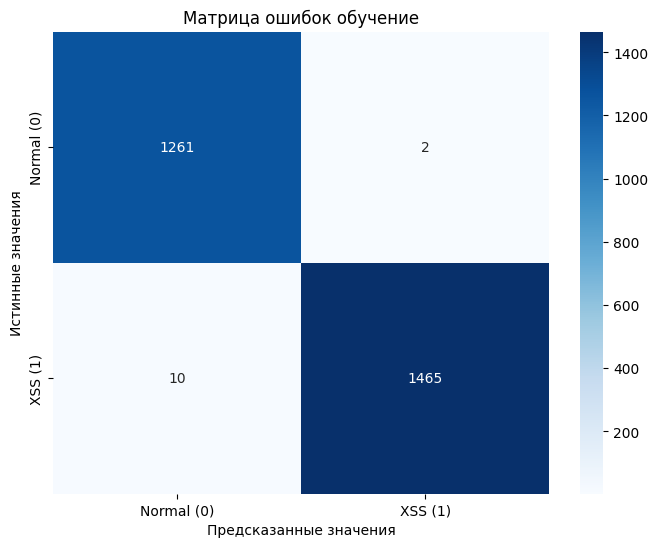

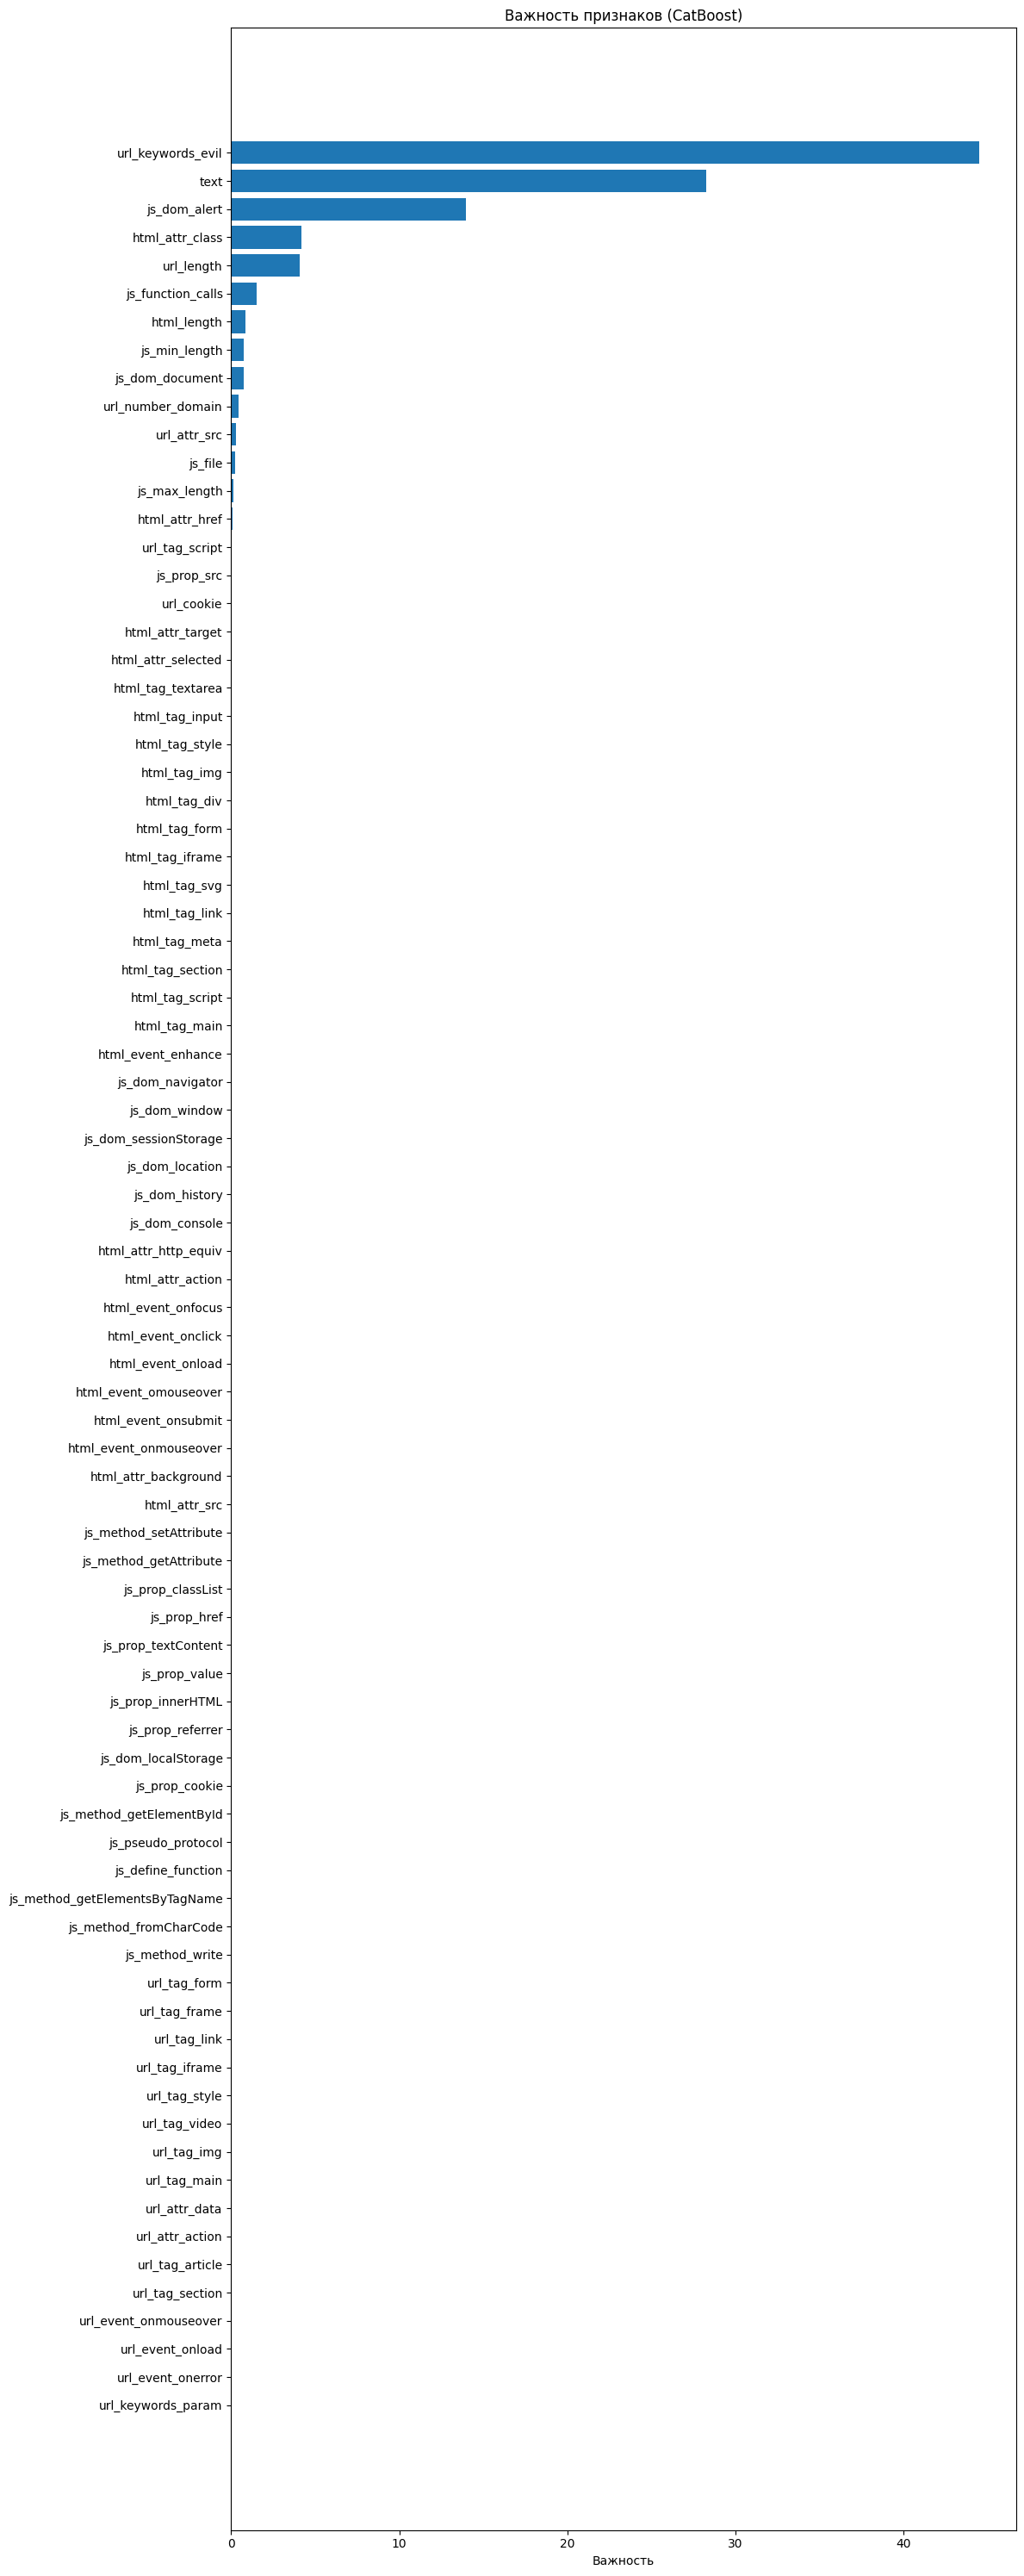

💾 Модель сохранена:
  - ./model/catboost_xss_model.cbm (модель)
  - ./model/model_metadata.pkl (метаданные)


In [9]:
best_params['feature_weights'] = feature_weights
best_params['task_type'] = 'GPU'
# best_params.pop('colsample_bylevel')

model = train_final_model(X, y, cat_features, best_params)

importance_df = analyze_feature_importance(model, X)

model_filename, metadata_filename = learn_detector.save_model(
    model, X.columns, cat_features)

In [10]:
print("\n🧪 Тестирование модели на примерах:")

test_cases = [
    "<script>alert('XSS')</script>",
    "<div>Hello World</div>",
    "<img src=x onerror=alert(1)>",
    "<p>Normal paragraph</p>",
    "<svg onload=alert(document.cookie)>",
    "<a href='/about'>About</a>"
]

metadata = {'feature_names': list(X.columns), 'cat_features': cat_features}

for test in test_cases:
    result = learn_detector.predict_xss(model, test, metadata)
    print(f"\n📝 {result['text']}")
    print(
        f"   XSS: {result['is_xss']} | Вероятность: {result['probability']:.2%} | Риск: {result['risk_level']}")
    if 'triggered_features' in result:
        print(f"   Причины: {', '.join(result['triggered_features'])}")

print("\n" + "=" * 60)
print("✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!")
print("=" * 60)


🧪 Тестирование модели на примерах:

📝 <script>alert('XSS')</script>
   XSS: True | Вероятность: 99.69% | Риск: HIGH
   Причины: 

📝 <div>Hello World</div>
   XSS: False | Вероятность: 22.02% | Риск: LOW

📝 <img src=x onerror=alert(1)>
   XSS: True | Вероятность: 99.84% | Риск: HIGH
   Причины: 

📝 <p>Normal paragraph</p>
   XSS: False | Вероятность: 22.02% | Риск: LOW

📝 <svg onload=alert(document.cookie)>
   XSS: True | Вероятность: 99.82% | Риск: HIGH
   Причины: 

📝 <a href='/about'>About</a>
   XSS: False | Вероятность: 1.84% | Риск: LOW

✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!


In [11]:
# Инициализируем детектор
learn_detector = XSSLearnDetector()
learn_detector.model = model
learn_detector.metadata = metadata

# Тестируем
test_codes = [
    "Normal HTML:_|_<div class='test'>Hello</div>",
    "XSS:_|_<script>alert('hacked')</script>",
    "Tricky:_|_<img src='x' onerror='javascript:alert(1)'>",
    "Encoded:_|_%3Cscript%3Ealert('xss')%3C/script%3E"
]

print("\n🧪 Тестовые предсказания:")
for code in test_codes:
    result = learn_detector.predict_xss(
        model, code.split('_|_')[-1], metadata)
    print(f"\n📝 {result['text']}")
    print(
        f"   XSS: {result['is_xss']} | Вероятность: {result['probability']:.2%} | Риск: {result['risk_level']}")
    if 'triggered_features' in result:
        print(f"   Причины: {', '.join(result['triggered_features'])}")


🧪 Тестовые предсказания:

📝 <div class='test'>Hello</div>
   XSS: False | Вероятность: 4.15% | Риск: LOW

📝 <script>alert('hacked')</script>
   XSS: True | Вероятность: 99.69% | Риск: HIGH
   Причины: 

📝 <img src='x' onerror='javascript:alert(1)'>
   XSS: True | Вероятность: 99.83% | Риск: HIGH
   Причины: 

📝 %3Cscript%3Ealert('xss')%3C/script%3E
   XSS: True | Вероятность: 99.69% | Риск: HIGH
   Причины: 


✅ Модель успешно загружена
   Признаков: 81
   Категориальных: 45

🧪 Тестирование модели...
📊 Загружено 13226 примеров
✅ Confusion matrix сохранена как 'confusion_matrix_xss.png'


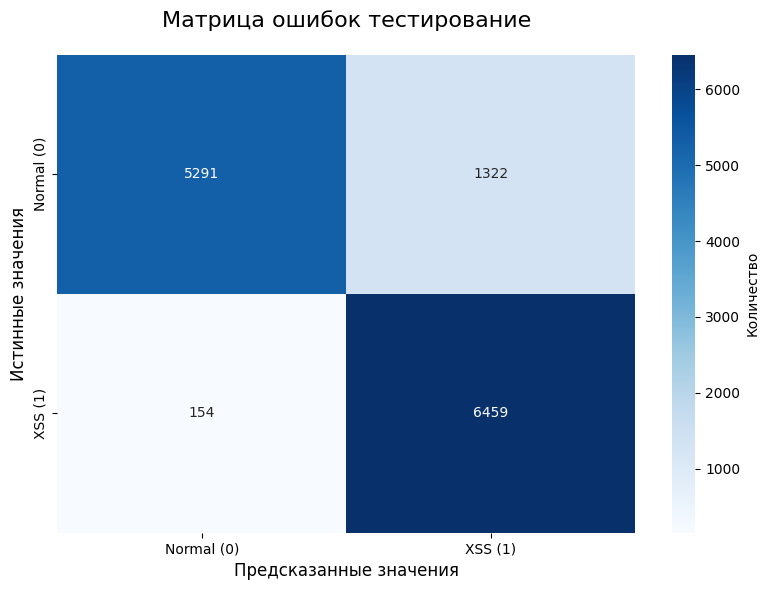


📊 Основные метрики:
True Negatives: 5291
False Positives: 1322
False Negatives: 154
True Positives: 6459
Точность: 88.8%
Precision: 83.01%
Recall: 97.67%
F1-score: 89.75%
FP-rate: 19.99%


In [12]:
test_detector = XSSTestDetector(model_filename, metadata_filename)

print("\n🧪 Тестирование модели...")

# Загрузка данных
df = pd.read_csv(test_filename, encoding='utf-8')
print(f"📊 Загружено {len(df)} примеров")

# Проверяем наличие истинных меток
if 'label' not in df.columns:
    print("❌ Нет истинных меток (label). Не могу построить confusion matrix.")
    exit()

# Прогнозирование
y_true = []
y_pred = []

for i, row in df.iterrows():
    text = row['text']
    true_label = int(row['label'])
    
    result = test_detector.predict(text, threshold=0.35)
    pred_label = int(result['is_xss'])
    
    y_true.append(true_label)
    y_pred.append(pred_label)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            cbar_kws={'label': 'Количество'},
            xticklabels=['Normal (0)', 'XSS (1)'],
            yticklabels=['Normal (0)', 'XSS (1)'])

plt.title('Матрица ошибок тестирование', fontsize=16, pad=20)
plt.ylabel('Истинные значения', fontsize=12)
plt.xlabel('Предсказанные значения', fontsize=12)
plt.tight_layout()

# Сохранение
plt.savefig('confusion_matrix_xss.png', dpi=150, bbox_inches='tight')
print("✅ Confusion matrix сохранена как 'confusion_matrix_xss.png'")

# Показ
plt.show()



# Просто вывод основных чисел
TN, FP, FN, TP = cm.ravel()

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
false_positive_rate = FP / (FP + TN) if (FP + TN) > 0 else 0

print(f"\n📊 Основные метрики:")
print(f"True Negatives: {TN}")
print(f"False Positives: {FP}")
print(f"False Negatives: {FN}")
print(f"True Positives: {TP}")
print(f"Точность: {(TP+TN)/(TP+TN+FP+FN):.1%}")
print("="*50)
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1-score: {f1_score:.2%}")
print(f"FP-rate: {false_positive_rate:.2%}")